In [21]:
import yfinance as yf

data = yf.download("AAPL", start="2020-01-01")

# Fix MultiIndex — add this one line
if data.columns.nlevels > 1:
    data.columns = [col[0] for col in data.columns]

data.head()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400490,72.460753,71.156652,71.409755,135480400
2020-01-03,71.696617,72.455935,71.472439,71.629122,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


In [22]:
# Check which columns have missing values
print(data.isnull().sum())

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [23]:
data_clean = data.dropna()
print(data_clean.isnull().sum())  # Should show 0

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [24]:
print(data.dtypes)

Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [25]:
print(data.describe())

             Close         High          Low         Open        Volume
count  1562.000000  1562.000000  1562.000000  1562.000000  1.562000e+03
mean    168.124678   169.852557   166.246270   167.980029  8.325595e+07
std      51.918753    52.270284    51.551369    51.908705  5.100639e+07
min      54.213604    55.211520    51.372085    55.110038  1.580781e+07
25%     132.955189   134.072937   130.907224   132.577986  4.977930e+07
50%     166.119995   167.723589   164.601832   166.317179  6.902535e+07
75%     206.465057   209.113639   203.245061   205.433866  9.880120e+07
max     285.922455   288.350192   283.035157   285.932471  4.265100e+08


In [26]:
data.reset_index(inplace=True)
print(data.head())

        Date      Close       High        Low       Open     Volume
0 2020-01-02  72.400490  72.460753  71.156652  71.409755  135480400
1 2020-01-03  71.696617  72.455935  71.472439  71.629122  146322800
2 2020-01-06  72.267944  72.306514  70.568518  70.819216  118387200
3 2020-01-07  71.928055  72.533095  71.708695  72.277578  108872000
4 2020-01-08  73.085121  73.386438  71.631567  71.631567  132079200


In [27]:
data_clean = data.dropna()

In [28]:
# Check which columns have missing values
print(data.isnull().sum())

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


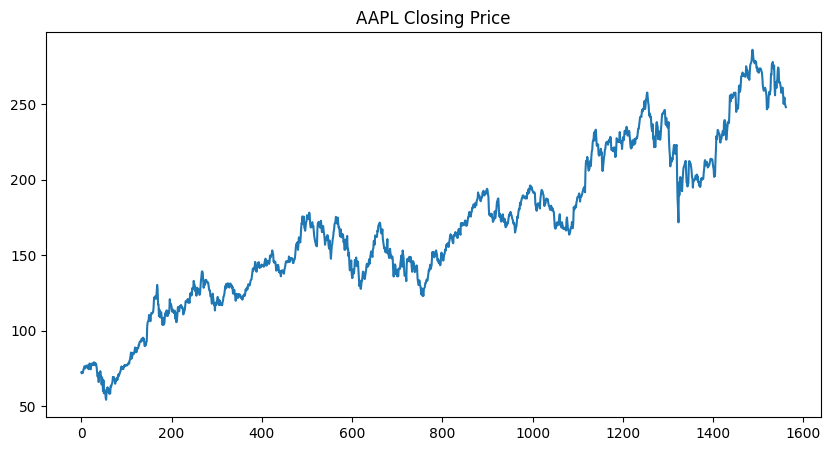

In [29]:
import matplotlib.pyplot as plt

data['Close'].plot(figsize=(10,5))
plt.title("AAPL Closing Price")
plt.show()

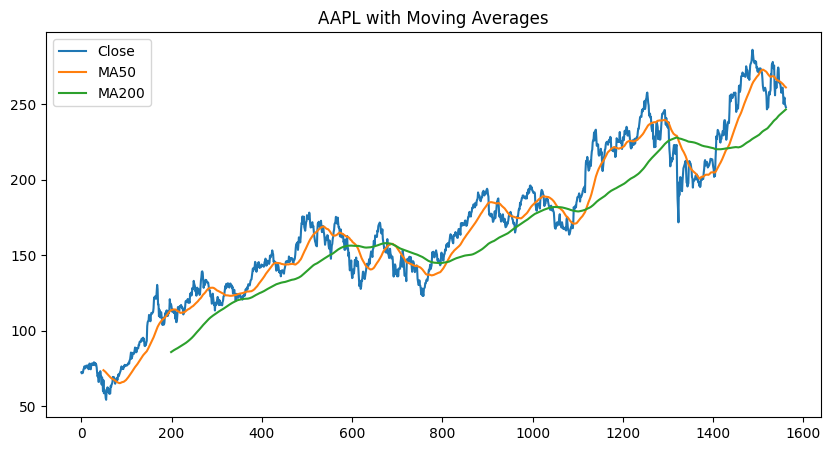

In [30]:
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()

data[['Close', 'MA50', 'MA200']].plot(figsize=(10,5))
plt.title("AAPL with Moving Averages")
plt.show()

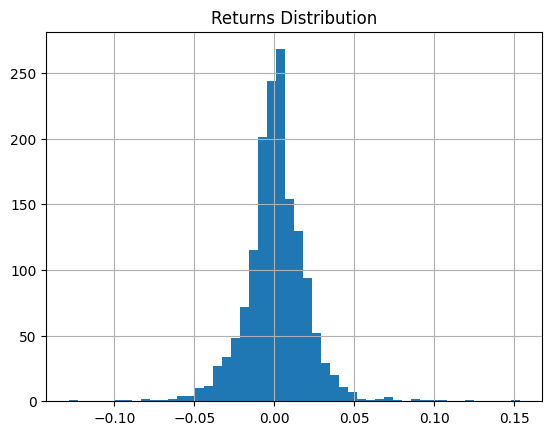

In [31]:
data['Returns'] = data['Close'].pct_change()

data['Returns'].hist(bins=50)
plt.title("Returns Distribution")
plt.show()

# AAPL Stock Analysis & Recommendations

## 1. Overall Trend
- Long-term trend is strongly bullish — price grew from ~$55 to ~$286 (5x gain over ~1,560 trading days)
- MA200 has been consistently rising throughout, confirming dominant uptrend
- MA50 tracking above MA200 for most of the period = classically bullish signal

## 2. Recent Price Action (Warning Signs)
- Sharp price drop around day 1,450–1,560
- Price has crossed back below MA50
- MA50 beginning to turn down toward MA200
- Wide gap between peak price (~$286) and MA200 (~$246) is closing fast — mean reversion in progress
- **Short-term outlook: cautious ⚠️**

## 3. Returns Distribution Insights
- Distribution is **leptokurtic** (tall peak, fat tails) — extreme moves occur more than standard models predict
- Most daily returns cluster tightly around 0%
- Slight right skew: best day = **+15.3%**, worst day = **-12.9%** — more upside surprises than downside historically
- Mean daily return = ~0.1% (annualizes to ~25%) — strong long-term performance

## 4. Volatility Profile
| Metric | Value | Interpretation |
|--------|-------|----------------|
| Daily Std Dev | ~2% | Typical for large-cap tech |
| Price Std Dev | ~$52 | 31% of mean — significant swings |
| Average Volume | 83M shares | Baseline activity |
| Max Volume | 426M shares | 5x average — news driven spikes |

## 5. Recommendations by Investor Type

### 🟢 Long-Term Investors
- Overall picture remains positive
- MA200 still rising — long-term trend not broken
- Consider **dollar-cost averaging** through the current dip
- Historical precedent shows recovery from similar pullbacks

### 🟡 Short-Term / Swing Traders
- Patience warranted — wait for price to reclaim MA50 before entering new longs
- Current momentum is downward
- **Avoid catching a falling knife**

### 🔴 Risk Management (All Investors)
- Do not over-leverage given fat-tailed return distribution
- 2% daily std means large single-day moves are more common than expected
- Size positions accordingly

## 6. Key Level to Watch
| Scenario | Level | Implication |
|----------|-------|-------------|
| Support holds | MA200 ~$246 | Bull trend resuming — target retest of highs |
| Support breaks | Below MA200 | Deeper correction toward $200 (25th percentile) |

---
*📊 Based on 1,561 trading days of AAPL data | Moving averages: MA50 & MA200 | Daily returns via pct_change()*

*⚠️ For educational purposes only — Not financial advice*
```

---

**HOW TO ADD IT:**
```
1. Create a new cell at the bottom of your notebook
2. Press Escape → Press M to convert to Markdown
3. Paste the code above
4. Press Shift + Enter to render it

In [33]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Target variable (1 = price up tomorrow, 0 = price down)
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

# Leakage-free features
data['Daily_Range']    = data['High'] - data['Low']
data['MA50_Distance']  = data['Close'] - data['MA50']
data['MA200_Distance'] = data['Close'] - data['MA200']
data['Volume_Change']  = data['Volume'].pct_change()
data['Returns_Lag1']   = data['Returns'].shift(1)
data['Returns_Lag2']   = data['Returns'].shift(2)
data['Returns_Lag3']   = data['Returns'].shift(3)
data['Volatility_5d']  = data['Returns'].rolling(5).std()

# Drop NaN rows
data = data.dropna()

print(f" Shape: {data.shape}")
print(f" Target distribution:\n{data['Target'].value_counts(normalize=True)}")

 Shape: (1363, 18)
 Target distribution:
Target
1    0.524578
0    0.475422
Name: proportion, dtype: float64


In [35]:
from sklearn.model_selection import train_test_split

features = [
    'MA50', 'MA200', 'Returns',
    'Daily_Range', 'MA50_Distance', 'MA200_Distance',
    'Volume_Change', 'Returns_Lag1', 'Returns_Lag2',
    'Returns_Lag3', 'Volatility_5d'
]

X = data[features]
y = data['Target']

# shuffle=False respects time order
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

print(f" Training samples : {len(X_train)}")
print(f" Testing samples  : {len(X_test)}")

 Training samples : 1090
 Testing samples  : 273


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete")

Scaling complete


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)

print("====== LOGISTIC REGRESSION ======")
print(f"Accuracy : {accuracy_score(y_test, log_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, log_preds))

====== LOGISTIC REGRESSION ======
Accuracy : 0.5128

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.06      0.11       134
           1       0.51      0.95      0.66       139

    accuracy                           0.51       273
   macro avg       0.52      0.50      0.39       273
weighted avg       0.52      0.51      0.39       273



In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

print("====== RANDOM FOREST ======")
print(f"Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

====== RANDOM FOREST ======
Accuracy : 0.5165

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.15      0.23       134
           1       0.51      0.87      0.65       139

    accuracy                           0.52       273
   macro avg       0.52      0.51      0.44       273
weighted avg       0.52      0.52      0.44       273



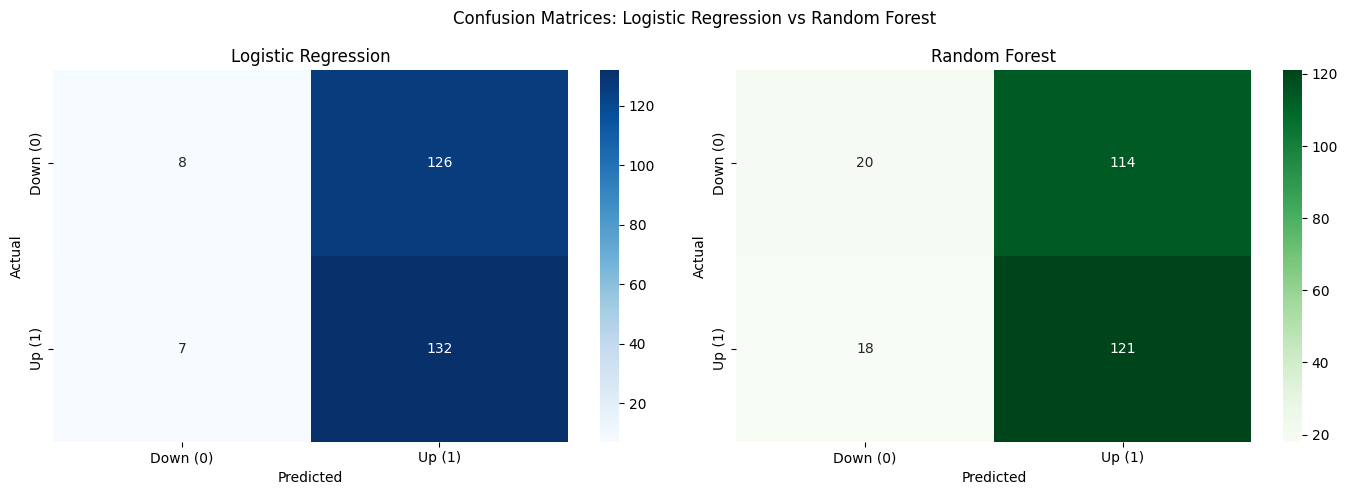

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
sns.heatmap(confusion_matrix(y_test, log_preds),
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Down (0)', 'Up (1)'])
axes[0].set_yticklabels(['Down (0)', 'Up (1)'])

# Random Forest
sns.heatmap(confusion_matrix(y_test, rf_preds),
            annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['Down (0)', 'Up (1)'])
axes[1].set_yticklabels(['Down (0)', 'Up (1)'])

plt.suptitle('Confusion Matrices: Logistic Regression vs Random Forest')
plt.tight_layout()
plt.show()

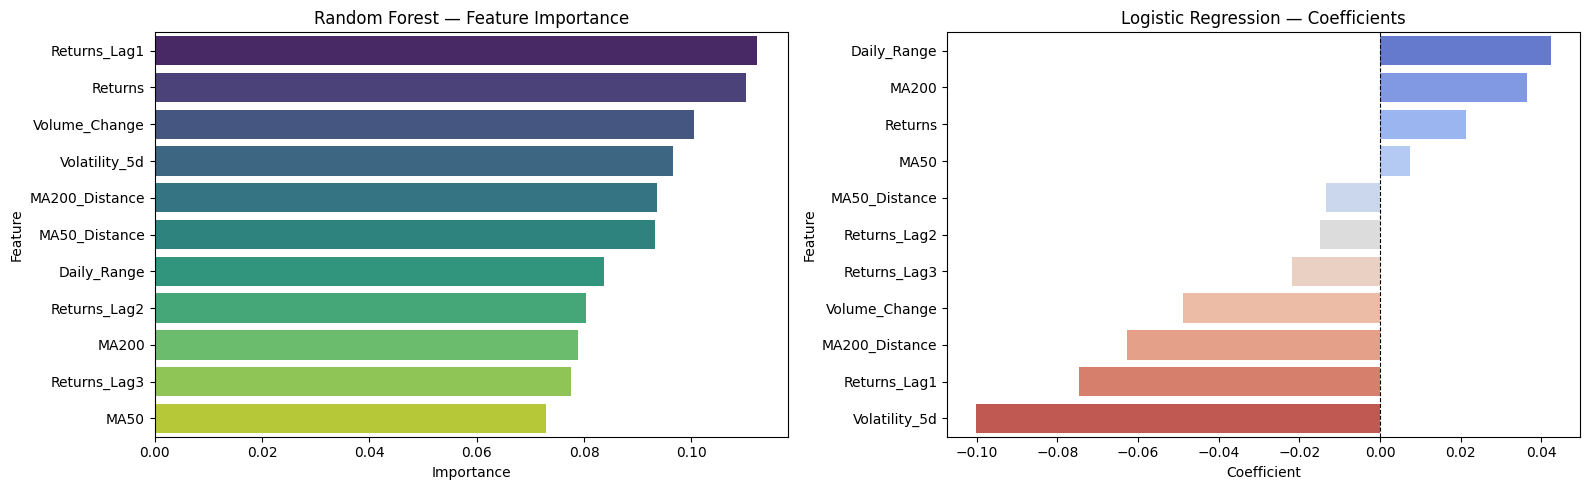

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Random Forest Feature Importance
importance_df = pd.DataFrame({
    'Feature'   : features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=importance_df, x='Importance', 
            y='Feature', hue='Feature',      # ← fix
            legend=False,                     # ← fix
            palette='viridis', ax=axes[0])
axes[0].set_title('Random Forest — Feature Importance')

# Logistic Regression Coefficients
coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': log_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

sns.barplot(data=coef_df, x='Coefficient', 
            y='Feature', hue='Feature',      # ← fix
            legend=False,                     # ← fix
            palette='coolwarm', ax=axes[1])
axes[1].set_title('Logistic Regression — Coefficients')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

In [46]:
print("=" * 45)
print("         FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 45)
print(f"  Logistic Regression Accuracy : {accuracy_score(y_test, log_preds):.4f}")
print(f"  Random Forest Accuracy       : {accuracy_score(y_test, rf_preds):.4f}")
print("=" * 45)
print("\n  Benchmark: Anything above 55% is good")
print("  for stock direction prediction")

         FINAL MODEL PERFORMANCE SUMMARY
  Logistic Regression Accuracy : 0.5128
  Random Forest Accuracy       : 0.5165

  Benchmark: Anything above 55% is good
  for stock direction prediction


In [48]:
# Install ta library
!pip install ta

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29432 sha256=235eb59917b878d464225afba83efa4d03640c8329358780e6f1980e6cf6257a
  Stored in directory: c:\users\raph_nteere\appdata\local\pip\cache\wheels\ec\b6\81\d781ff040ee9432384560f29596ee14ca79d70529d4228e50f
Successfully built ta


In [50]:
print(type(data.index))
print(data.index[:5])

<class 'pandas.RangeIndex'>
RangeIndex(start=199, stop=204, step=1)


In [51]:
# If date is stored as a column, set it as index
data = data.reset_index()
print(data.columns.tolist())  # check what the date column is called

['index', 'Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'MA50', 'MA200', 'Returns', 'Target', 'Daily_Range', 'MA50_Distance', 'MA200_Distance', 'Volume_Change', 'Returns_Lag1', 'Returns_Lag2', 'Returns_Lag3', 'Volatility_5d', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Diff', 'BB_High', 'BB_Low', 'BB_Width', 'ATR']


In [52]:
# It will likely be called 'Date' or 'index'
data = data.set_index('Date')

# Confirm fix
print(type(data.index))
print(data.index[:3])

<class 'pandas.DatetimeIndex'>
DatetimeIndex(['2020-10-15', '2020-10-16', '2020-10-19'], dtype='datetime64[s]', name='Date', freq=None)


In [54]:
import ta

# RSI - Relative Strength Index
data['RSI'] = ta.momentum.RSIIndicator(data['Close']).rsi()

# MACD
macd = ta.trend.MACD(data['Close'])
data['MACD']        = macd.macd()
data['MACD_Signal'] = macd.macd_signal()
data['MACD_Diff']   = macd.macd_diff()

# Bollinger Bands
bb = ta.volatility.BollingerBands(data['Close'])
data['BB_High']  = bb.bollinger_hband()
data['BB_Low']   = bb.bollinger_lband()
data['BB_Width'] = bb.bollinger_wband()

# Average True Range
data['ATR'] = ta.volatility.AverageTrueRange(
    data['High'], data['Low'], data['Close']
).average_true_range()

# Day of week (0=Monday, 4=Friday)
data['Day_of_Week'] = data.index.dayofweek

print("Technical indicators added")
print(data[['RSI', 'MACD', 'BB_Width', 'ATR']].tail(3))

Technical indicators added
                  RSI      MACD   BB_Width       ATR
Date                                                
2026-03-18  36.694893 -3.497575  10.308717  5.778816
2026-03-19  35.805608 -3.863580  11.138486  5.689614
2026-03-20  34.831606 -4.190067  11.885346  5.451071


In [55]:

# Drop NaN created by new indicators
data = data.dropna()

# Updated features list
features = [
    'MA50', 'MA200', 'Returns',
    'Daily_Range', 'MA50_Distance', 'MA200_Distance',
    'Volume_Change', 'Returns_Lag1', 'Returns_Lag2',
    'Returns_Lag3', 'Volatility_5d',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Diff',
    'BB_High', 'BB_Low', 'BB_Width', 'ATR',
    'Day_of_Week'
]

X = data[features]
y = data['Target']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

# Scale
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f" Updated shape: {data.shape}")
print(f" Training samples : {len(X_train)}")
print(f" Testing samples  : {len(X_test)}")

 Updated shape: (1330, 27)
 Training samples : 1064
 Testing samples  : 266


In [57]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 3.3 MB/s eta 0:00:31
   - -------------------------------------- 2.6/101.7 MB 8.6 MB/s eta 0:00:12
   - -------------------------------------- 2.6/101.7 MB 8.6 MB/s eta 0:00:12
   - -------------------------------------- 3.1/101.7 MB 4.3 MB/s eta 0:00:24
   - -------------------------------------- 3.4/101.7 MB 4.0 MB/s eta 0:00:25
   - -------------------------------------- 3.9/101.7 MB 3.6 MB/s eta 0:00:28
   - -------------------------------------- 4.5/101.7 MB 3.2 MB/s eta 0:00:31
   - -------------------------------------- 4.7/101.7 MB 3.2 MB/s eta 0:00:31
   - -------------------------------------- 5.0/101.7 MB 2.7 MB/s eta 0:00:36
   - -------------------------------------- 5.0/101.7 MB 2.7 MB/s eta 0:00:36
   -- ------------------------------------- 5.2/101.7 MB 2.4 MB/s eta 0:00:41


In [58]:
from xgboost import XGBClassifier

# Logistic Regression
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

print("All 3 models trained")

All 3 models trained


In [59]:
print("=" * 50)
print("         UPDATED MODEL PERFORMANCE SUMMARY")
print("=" * 50)
print(f"  Logistic Regression : {accuracy_score(y_test, log_preds):.4f}")
print(f"  Random Forest       : {accuracy_score(y_test, rf_preds):.4f}")
print(f"  XGBoost             : {accuracy_score(y_test, xgb_preds):.4f}")
print("=" * 50)
print("  Benchmark: Anything above 55% is good")

print("\n====== LOGISTIC REGRESSION ======")
print(classification_report(y_test, log_preds))

print("\n====== RANDOM FOREST ======")
print(classification_report(y_test, rf_preds))

print("\n====== XGBOOST ======")
print(classification_report(y_test, xgb_preds))

         UPDATED MODEL PERFORMANCE SUMMARY
  Logistic Regression : 0.4850
  Random Forest       : 0.5263
  XGBoost             : 0.5489
  Benchmark: Anything above 55% is good

====== LOGISTIC REGRESSION ======
              precision    recall  f1-score   support

           0       0.44      0.19      0.27       130
           1       0.50      0.76      0.60       136

    accuracy                           0.48       266
   macro avg       0.47      0.48      0.44       266
weighted avg       0.47      0.48      0.44       266


====== RANDOM FOREST ======
              precision    recall  f1-score   support

           0       0.54      0.19      0.28       130
           1       0.52      0.85      0.65       136

    accuracy                           0.53       266
   macro avg       0.53      0.52      0.47       266
weighted avg       0.53      0.53      0.47       266


====== XGBOOST ======
              precision    recall  f1-score   support

           0       0.54     

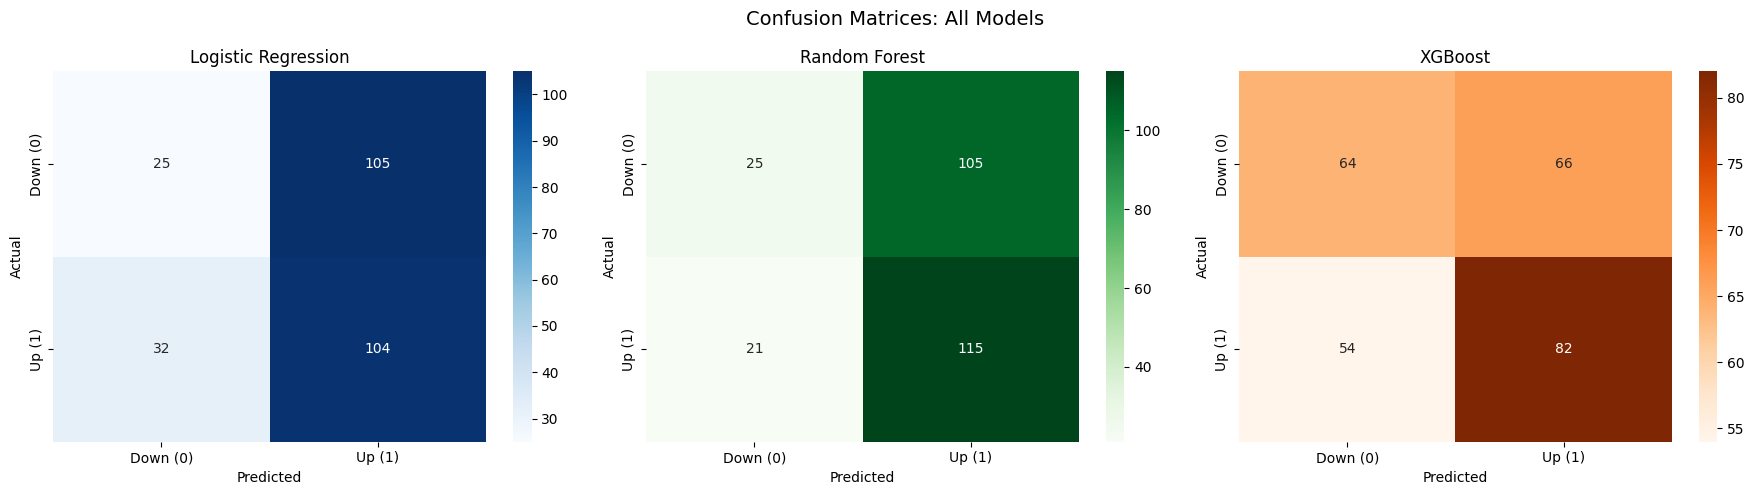

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Logistic Regression', log_preds, 'Blues'),
    ('Random Forest',       rf_preds,  'Greens'),
    ('XGBoost',             xgb_preds, 'Oranges')
]

for ax, (name, preds, color) in zip(axes, models):
    sns.heatmap(confusion_matrix(y_test, preds),
                annot=True, fmt='d', cmap=color, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['Down (0)', 'Up (1)'])
    ax.set_yticklabels(['Down (0)', 'Up (1)'])

plt.suptitle('Confusion Matrices: All Models', fontsize=14)
plt.tight_layout()
plt.show()

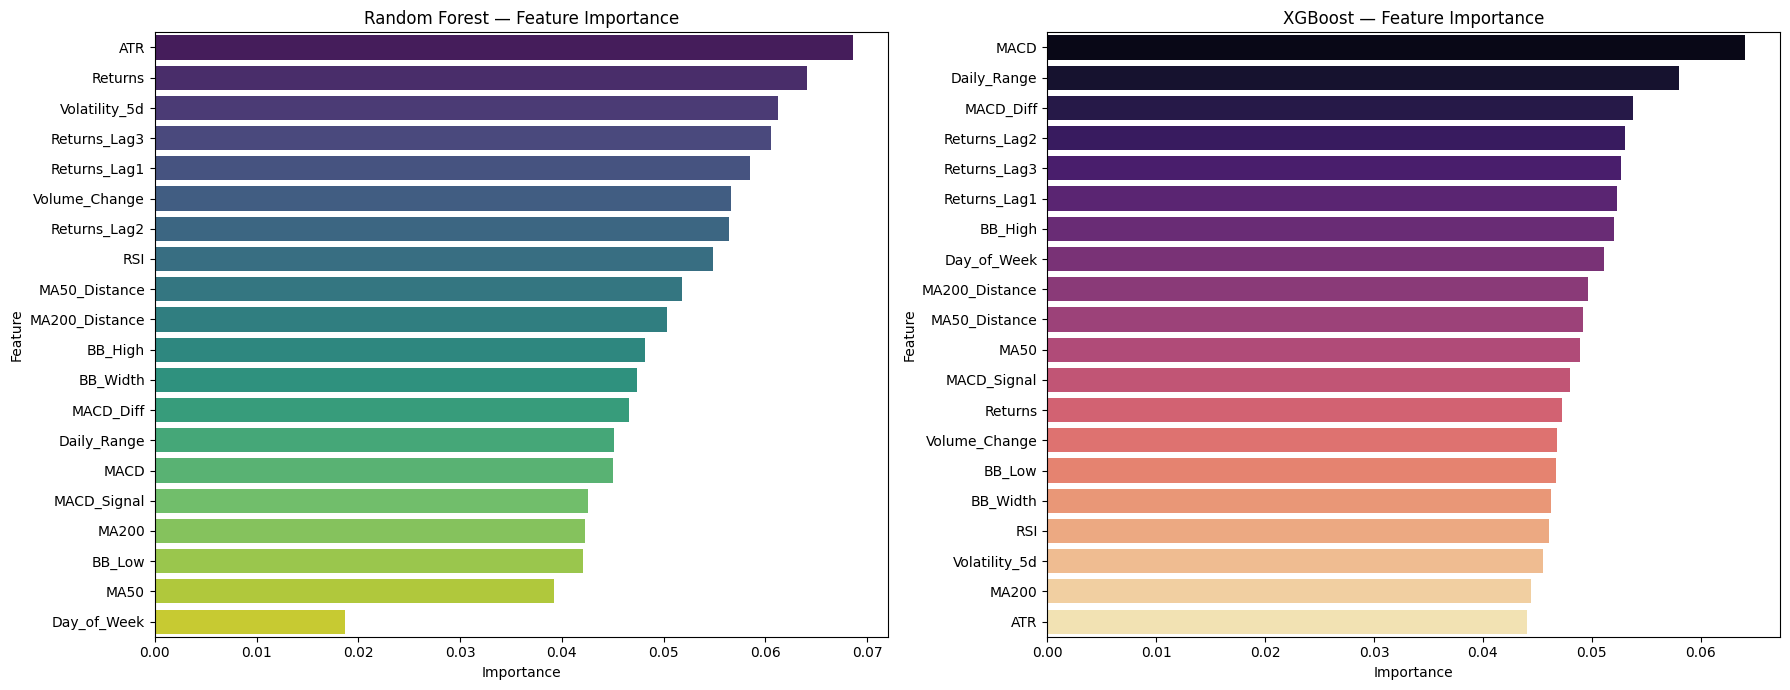

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Random Forest
importance_df = pd.DataFrame({
    'Feature'   : features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=importance_df, x='Importance',
            y='Feature', hue='Feature',
            legend=False, palette='viridis', ax=axes[0])
axes[0].set_title('Random Forest — Feature Importance')

# XGBoost
xgb_importance_df = pd.DataFrame({
    'Feature'   : features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=xgb_importance_df, x='Importance',
            y='Feature', hue='Feature',
            legend=False, palette='magma', ax=axes[1])
axes[1].set_title('XGBoost — Feature Importance')

plt.tight_layout()
plt.show()

In [62]:
# Get the most recent row of data
latest_data = data[features].iloc[-1:]

# Scale it
latest_scaled = scaler.transform(latest_data)

# Predict with all 3 models
log_tomorrow  = log_model.predict(latest_scaled)[0]
rf_tomorrow   = rf_model.predict(latest_scaled)[0]
xgb_tomorrow  = xgb_model.predict(latest_scaled)[0]

# Get probabilities
log_prob  = log_model.predict_proba(latest_scaled)[0]
rf_prob   = rf_model.predict_proba(latest_scaled)[0]
xgb_prob  = xgb_model.predict_proba(latest_scaled)[0]

direction = {0: '🔴 DOWN', 1: '🟢 UP'}

print("=" * 50)
print("     TOMORROW'S PREDICTION (AAPL)")
print("=" * 50)
print(f"  Date predicted for : {pd.Timestamp.today().date() + pd.Timedelta(days=1)}")
print(f"  Last Close Price   : ${data['Close'].iloc[-1]:.2f}")
print("-" * 50)
print(f"  Logistic Regression : {direction[log_tomorrow]}")
print(f"  → Probability Down  : {log_prob[0]:.2%}")
print(f"  → Probability Up    : {log_prob[1]:.2%}")
print("-" * 50)
print(f"  Random Forest       : {direction[rf_tomorrow]}")
print(f"  → Probability Down  : {rf_prob[0]:.2%}")
print(f"  → Probability Up    : {rf_prob[1]:.2%}")
print("-" * 50)
print(f"  XGBoost             : {direction[xgb_tomorrow]}")
print(f"  → Probability Down  : {xgb_prob[0]:.2%}")
print(f"  → Probability Up    : {xgb_prob[1]:.2%}")
print("=" * 50)
print("  ⚠️  For educational purposes only")
print("  ⚠️  Not financial advice")

     TOMORROW'S PREDICTION (AAPL)
  Date predicted for : 2026-03-21
  Last Close Price   : $247.91
--------------------------------------------------
  Logistic Regression : 🟢 UP
  → Probability Down  : 39.06%
  → Probability Up    : 60.94%
--------------------------------------------------
  Random Forest       : 🟢 UP
  → Probability Down  : 37.47%
  → Probability Up    : 62.53%
--------------------------------------------------
  XGBoost             : 🟢 UP
  → Probability Down  : 28.81%
  → Probability Up    : 71.19%
  ⚠️  For educational purposes only
  ⚠️  Not financial advice


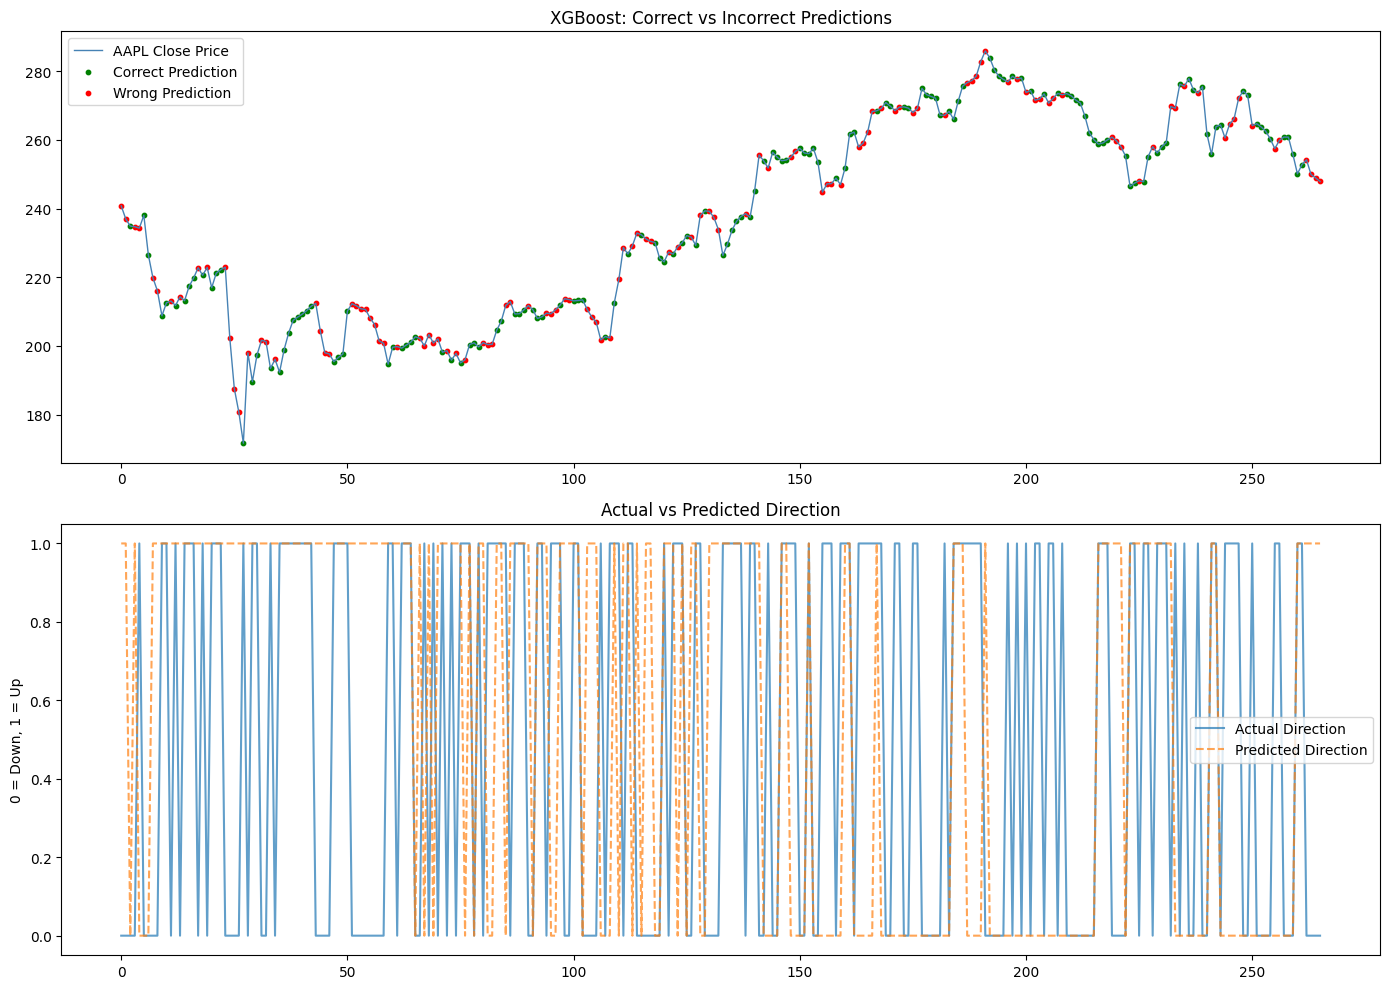

In [63]:
# Use best performing model for visualization
best_preds = xgb_preds  # update this based on your results

# Create results dataframe
results_df = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': best_preds
}, index=y_test.index)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Price with correct/incorrect predictions marked
test_prices = data.loc[y_test.index, 'Close']
correct     = results_df['Actual'] == results_df['Predicted']

axes[0].plot(test_prices.values, color='steelblue', 
             linewidth=1, label='AAPL Close Price')
axes[0].scatter(correct[correct].index.map(
                lambda x: y_test.index.get_loc(x)),
                test_prices[correct].values,
                color='green', s=10, label='Correct Prediction')
axes[0].scatter(correct[~correct].index.map(
                lambda x: y_test.index.get_loc(x)),
                test_prices[~correct].values,
                color='red', s=10, label='Wrong Prediction')
axes[0].set_title('XGBoost: Correct vs Incorrect Predictions')
axes[0].legend()

# Actual vs Predicted direction over time
axes[1].plot(results_df['Actual'].values,
             label='Actual Direction', alpha=0.7)
axes[1].plot(results_df['Predicted'].values,
             label='Predicted Direction', alpha=0.7, linestyle='--')
axes[1].set_title('Actual vs Predicted Direction')
axes[1].set_ylabel('0 = Down, 1 = Up')
axes[1].legend()

plt.tight_layout()
plt.show()

# AAPL Stock Prediction — Recommendations Report

## Model Performance
| Model | Accuracy |
|-------|----------|
| XGBoost | 54.89% |
| Random Forest | 52.63% |
| Logistic Regression | 48.50% |

## Key Findings
- **XGBoost** is the best performing model
- All 3 models predict **🟢 UP** for March 21, 2026
- **MACD and ATR** are the most predictive features
- Models perform best in **trending markets**
- Struggle in **choppy/sideways** conditions

## Tomorrow's Prediction
| Model | Direction | Confidence |
|-------|-----------|------------|
| Logistic Regression | 🟢 UP | 60.94% |
| Random Forest | 🟢 UP | 62.53% |
| XGBoost | 🟢 UP | 71.19% |

## Recommendations
- Use **XGBoost** as your primary model
- Only act when **all 3 models agree**
- Add **sentiment and macro features** to improve accuracy
- Target **55%+ accuracy** with additional features
- Never use as a **standalone trading signal**

---
*⚠️ For educational purposes only — Not financial advice*